# 03: Parametric curve fitting: Nelson-Siegel and Svensson

## Objective

Notebooks 01 and 02 built a curve by bootstrapping: the curve was forced through
every quote exactly, and an interpolation rule filled the gaps. That approach
treats each quote as error-free. It is the right choice when the quotes are the
instruments you are actually going to hedge with, and it is what a trading desk
marks its book against.

It is the wrong choice for several other jobs. A central bank publishing a
reference curve does not want its estimate to jump every time one bond in the
sample goes special in repo. A risk manager who wants to describe a curve move
in three numbers cannot do it with 40 bootstrapped pillars. And anyone
extrapolating past the longest traded maturity has no quotes left to interpolate
between, so something has to supply the shape.

Parametric models answer those jobs. They impose a functional form on the whole
term structure and fit its handful of parameters by least squares, accepting a
residual at every quote in exchange for smoothness, parsimony and a curve that is
defined everywhere. This notebook fits the two standard ones: Nelson-Siegel
(1987) with four parameters, and its Svensson (1994) extension with six
parameters. It applies these to the European Central Bank's published euro area
spot curve and measures what the two extra parameters buy.

## Data

One dataset, from the snapshot committed at `data/snapshots/2026-07-24/`:

- `ecb_spot_curve`: 14 zero rates, 1 to 30 years, from the ECB's AAA-rated euro
  area government bond yield curve. Continuously compounded, so they feed the
  models without conversion.
- `ecb_svensson_parameters`: the six Svensson parameters the ECB published for
  the same date. The ECB quotes its betas in percent; the code below divides by
  100. The taus are in years and are used directly.

The second dataset is what makes this notebook more than a curve-fitting
exercise, and it needs to be introduced honestly rather than saved for a reveal.
The ECB series key is `YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_<TENOR>`. The `SV_C_YM`
segment records the estimation method: **S**vensson model, **c**ontinuous
compounding, **y**ield error **m**inimisation. The published spot rates are not
raw market observations. They are readings taken off a Svensson curve that the
ECB had already fitted to its bond sample.

That has a consequence which is stated here at the top rather than presented
later as a result: fitting a Svensson model to these 14 points is fitting a model
to data generated by that same model. The residual should be numerically zero,
and it is. What the exercise legitimately establishes is a **verification** (an
independent optimiser written against a different objective function that
recovers the ECB's six published parameters from nothing but the curve they
generated). It
does not establish that Svensson fits real bond prices well, and no claim of that
kind is made below.

The Nelson-Siegel comparison, though, becomes cleaner rather than weaker under
these conditions. Because the target is an exact Svensson curve, the
Nelson-Siegel residual is not contaminated by bid-offer noise, liquidity premia
or bonds trading special. It is a pure measurement of one thing: what is lost by
deleting the second curvature term.

## Theory

Nelson and Siegel proposed writing the *instantaneous forward* rate as a solution
to a second-order differential equation with equal roots, which produces

$$f(t) = \beta_0 + \beta_1 e^{-t/\tau} + \beta_2 \frac{t}{\tau} e^{-t/\tau}.$$

Integrating and dividing by $t$ gives the zero rate, which is the form actually
fitted:

$$z(t) = \beta_0 + \beta_1 \frac{1 - e^{-t/\tau}}{t/\tau}
         + \beta_2 \left( \frac{1 - e^{-t/\tau}}{t/\tau} - e^{-t/\tau} \right).$$

The three loadings are what give the model its interpretation. The loading on
$\beta_0$ is 1 at every maturity, so $\beta_0$ moves the whole curve: the level
factor. The loading on $\beta_1$ is 1 at $t = 0$ and decays to 0, so $\beta_1$
moves the short end relative to the long end: the slope factor. The loading on
$\beta_2$ is 0 at both ends and humped in between, so $\beta_2$ bends the middle:
the curvature factor. Consequently $\beta_0$ is the asymptotic long rate,
$\beta_0 + \beta_1$ is the instantaneous short rate, and $\tau$ sets where the
hump sits.

Those three shapes are close to what principal component analysis extracts
empirically from historical yield changes, which is why the same level-slope-
curvature vocabulary appears in both literatures. Notebook 05 runs the PCA and
the correspondence can be checked there rather than asserted here.

Svensson's extension adds a second curvature term with its own decay:

$$f(t) = \beta_0 + \beta_1 e^{-t/\tau_1} + \beta_2 \frac{t}{\tau_1} e^{-t/\tau_1}
         + \beta_3 \frac{t}{\tau_2} e^{-t/\tau_2}.$$

With $\tau_2 \neq \tau_1$ the curve can bend twice, at two separate horizons.
The practical motivation is the long end. A single hump forces the curve to
approach $\beta_0$ monotonically once past it, so a term structure that rises,
flattens and then rolls over (as when a 15 to 30 year segment rises, flattens,
and then rolls over due to duration demand from pension funds and insurers
bidding up very long bonds) cannot be reproduced by four parameters. It can by
six.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.curves.parametric import FitError, NelsonSiegel, Svensson
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

spot = snapshot.load("ecb_spot_curve").sort_values("tenor_years")
times = spot["tenor_years"].to_numpy(dtype=float)
zeros = spot["zero_rate"].to_numpy(dtype=float)

published = snapshot.load("ecb_svensson_parameters").set_index("parameter")["value"]

print(f"ECB euro area AAA spot curve, {ASOF}, {len(times)} tenors")
print(f"{'tenor (y)':>10} {'zero (%)':>10}")
for t, z in zip(times, zeros, strict=True):
    print(f"{t:>10.0f} {100 * z:>10.4f}")

print()
print("ECB published Svensson parameters (betas in percent, taus in years)")
for name, value in published.items():
    print(f"{name:>8} {value:>16.10f}")

ECB euro area AAA spot curve, 2026-07-24, 14 tenors
 tenor (y)   zero (%)
         1     2.6414
         2     2.7720
         3     2.8155
         4     2.8504
         5     2.8954
         6     2.9512
         7     3.0137
         8     3.0791
         9     3.1442
        10     3.2070
        15     3.4573
        20     3.5929
        25     3.6377
        30     3.6200

ECB published Svensson parameters (betas in percent, taus in years)
   BETA0     1.3260646820
   BETA1     0.8461755436
   BETA2     2.0922416380
   BETA3     7.3512863000
    TAU1     1.0791595160
    TAU2    15.4469075500


The curve rises from 2.64% at one year to 3.64% at 25 years and then *falls* to
3.62% at 30 years. That inversion in the last segment is small, but it is the
feature that will separate the two models, so it is worth noting before any
fitting happens.

## Methodology

Both models are fitted by minimising the root mean squared error between the
model zero rate and the observed zero rate across the 14 tenors. Two aspects of
how the library does that matter for reading the results.

**The optimiser is global, not local.** Nelson-Siegel-type objective functions are
not convex in $\tau$, and a gradient descent started from a poor guess lands in a
local minimum routinely. This is a well documented nuisance in the fitting
literature, not a hypothetical. `yieldcurve.curves.parametric` uses
`scipy.optimize.differential_evolution`, a population-based global search, with a
final local polish. It runs with a fixed seed (`_SEED = 20260727`), so the fit is
reproducible: rerunning this notebook returns the same parameters, which is a
requirement for anything that feeds a valuation.

**The parameters are bounded, and the bounds are part of the model.** The library
constrains $\beta_0 \in (10^{-6}, 0.25)$, the other betas to $\pm 0.25$, and both
taus to $(10^{-3}, 30)$ years. Svensson also requires
$\tau_2 - \tau_1 > 10^{-3}$, which stops the two hump terms collapsing onto each
other and becoming unidentified. Both models require
$\beta_0 + \beta_1 > 10^{-6}$, that is, a strictly positive instantaneous short
rate. Bounds like these are how a fitter is kept away from absurd regions, but
they are also a modelling choice with consequences, and the results below will
show one of them clearly.

The fitters also refuse to run underdetermined problems: Nelson-Siegel needs at
least four observations and Svensson at least six. Both raise `FitError` rather
than returning a fit that happens to interpolate.

In [2]:
try:
    Svensson.fit(times[:5], zeros[:5], ASOF)
except FitError as exc:
    print(f"FitError: {exc}")

ns = NelsonSiegel.fit(times, zeros, ASOF)
sv = Svensson.fit(times, zeros, ASOF)

print()
print("Nelson-Siegel (4 parameters)")
print(f"  beta0 {100 * ns.beta[0]:>12.6f} %   long-run level")
print(f"  beta1 {100 * ns.beta[1]:>12.6f} %   slope")
print(f"  beta2 {100 * ns.beta[2]:>12.6f} %   curvature")
print(f"  tau   {ns.tau:>12.6f}     years")
print(f"  implied short rate beta0 + beta1 = {100 * (ns.beta[0] + ns.beta[1]):.4f} %")

print()
print("Svensson (6 parameters)")
for i, label in enumerate(("level", "slope", "curvature 1", "curvature 2")):
    print(f"  beta{i} {100 * sv.beta[i]:>12.6f} %   {label}")
print(f"  tau1  {sv.tau[0]:>12.6f}     years")
print(f"  tau2  {sv.tau[1]:>12.6f}     years")
print(f"  implied short rate beta0 + beta1 = {100 * (sv.beta[0] + sv.beta[1]):.4f} %")

print()
print(f"RMSE Nelson-Siegel  {1e4 * ns.rmse(times, zeros):>12.4f} bp")
print(f"RMSE Svensson       {1e4 * sv.rmse(times, zeros):>12.2e} bp")

FitError: Svensson has 6 parameters; 5 observations cannot fit it



Nelson-Siegel (4 parameters)
  beta0     0.000100 %   long-run level
  beta1     2.549608 %   slope
  beta2     7.764479 %   curvature
  tau      30.000000     years
  implied short rate beta0 + beta1 = 2.5497 %

Svensson (6 parameters)
  beta0     1.326065 %   level
  beta1     0.846176 %   slope
  beta2     2.092242 %   curvature 1
  beta3     7.351286 %   curvature 2
  tau1      1.079160     years
  tau2     15.446908     years
  implied short rate beta0 + beta1 = 2.1722 %

RMSE Nelson-Siegel        3.4196 bp
RMSE Svensson           2.37e-08 bp


## Result 1: the fitted Svensson parameters are the ECB's parameters

The Svensson RMSE is $2.4 \times 10^{-8}$ basis points, which is the optimiser
converging to machine precision rather than fitting well. The reason is the one
set out at the top: the target curve was generated by a Svensson model, so an
exact fit exists and the search found it.

The check worth running is therefore not the residual but the parameters. If the
implementation is correct, the six numbers recovered from the curve should be the
six numbers the ECB published alongside it. Nothing in the fitting code ever sees
those published values.

In [3]:
recovered = {
    "BETA0": 100 * sv.beta[0],
    "BETA1": 100 * sv.beta[1],
    "BETA2": 100 * sv.beta[2],
    "BETA3": 100 * sv.beta[3],
    "TAU1": sv.tau[0],
    "TAU2": sv.tau[1],
}

print(f"{'parameter':>10} {'ECB published':>16} {'recovered':>16} {'difference':>14}")
for name, value in recovered.items():
    ref = float(published[name])
    print(f"{name:>10} {ref:>16.10f} {value:>16.10f} {value - ref:>14.2e}")

ecb_curve = Svensson(
    beta=tuple(float(published[f"BETA{i}"]) / 100 for i in range(4)),  # type: ignore[arg-type]
    tau=(float(published["TAU1"]), float(published["TAU2"])),
    reference_date=ASOF,
)
print()
print(
    f"RMSE of the ECB's own parameters against the ECB's own spot rates: "
    f"{1e4 * ecb_curve.rmse(times, zeros):.2e} bp"
)

 parameter    ECB published        recovered     difference
     BETA0     1.3260646820     1.3260646713      -1.07e-08
     BETA1     0.8461755436     0.8461755613       1.77e-08
     BETA2     2.0922416380     2.0922416324      -5.55e-09
     BETA3     7.3512863000     7.3512863324       3.24e-08
      TAU1     1.0791595160     1.0791595240       7.97e-09
      TAU2    15.4469075500    15.4469075444      -5.55e-09

RMSE of the ECB's own parameters against the ECB's own spot rates: 3.69e-08 bp


The six parameters agree to roughly eight significant figures. Two independent
routes, the ECB's estimation from its bond sample and a differential evolution
search here that only ever saw 14 spot rates, arrive at the same point in
parameter space.

This is a useful piece of evidence about the implementation, and it is worth
being precise about what it does and does not support.

It supports: the Svensson functional form coded in
`yieldcurve.curves.parametric` is the same functional form the ECB uses, in the
same compounding convention, with the same parameter scaling; and the optimiser
reliably finds the global minimum of a six-parameter non-convex problem rather
than stopping at a local one. A wrong sign, a $\tau$ in the wrong place or a
missing $t/\tau$ factor would all have produced a different parameter vector with
a small but non-zero residual, which is exactly the failure mode that is hard to
catch by eye on a plot.

It does not support: any claim that Svensson describes government bond prices
accurately. That question cannot be answered with data that a Svensson model
produced. Answering it needs a cross-section of individual bond prices and a
comparison of model prices against traded ones, a different exercise requiring
data this repository does not redistribute.

## Result 2: what the second hump is worth

Nelson-Siegel is the same model with $\beta_3$ deleted. Since the target is an
exact Svensson curve, every basis point of Nelson-Siegel residual is attributable
to that deletion and to nothing else.

In [4]:
ns_fit = np.array([ns.zero(t) for t in times])
sv_fit = np.array([sv.zero(t) for t in times])
ns_resid_bp = 1e4 * (ns_fit - zeros)
sv_resid_bp = 1e4 * (sv_fit - zeros)

print(f"{'tenor':>6} {'observed %':>11} {'NS %':>9} {'NS resid bp':>12} {'SV resid bp':>12}")
for t, z, f, rn, rs in zip(times, zeros, ns_fit, ns_resid_bp, sv_resid_bp, strict=True):
    print(f"{t:>6.0f} {100 * z:>11.4f} {100 * f:>9.4f} {rn:>12.2f} {rs:>12.2e}")

short = times <= 5
long = times >= 15
print()
print(f"Nelson-Siegel RMSE, all 14 tenors     {1e4 * ns.rmse(times, zeros):>8.2f} bp")
print(f"Nelson-Siegel RMSE, 1 to 5 years      {1e4 * ns.rmse(times[short], zeros[short]):>8.2f} bp")
print(f"Nelson-Siegel RMSE, 15 to 30 years    {1e4 * ns.rmse(times[long], zeros[long]):>8.2f} bp")
print(
    f"largest single residual               {np.abs(ns_resid_bp).max():>8.2f} bp "
    f"at {times[np.abs(ns_resid_bp).argmax()]:.0f} years"
)

 tenor  observed %      NS %  NS resid bp  SV resid bp
     1      2.6414    2.6343        -0.71    -2.94e-10
     2      2.7720    2.7142        -5.78     3.59e-09
     3      2.8155    2.7897        -2.59    -1.35e-08
     4      2.8504    2.8609         1.05     1.47e-08
     5      2.8954    2.9280         3.26    -1.24e-09
     6      2.9512    2.9912         4.00     2.87e-08
     7      3.0137    3.0506         3.69    -5.78e-08
     8      3.0791    3.1064         2.74     4.17e-09
     9      3.1442    3.1588         1.46     8.61e-11
    10      3.2070    3.2078         0.08     3.48e-08
    15      3.4573    3.4073        -5.00    -2.67e-08
    20      3.5929    3.5417        -5.12     2.79e-08
    25      3.6377    3.6236        -1.41    -2.23e-08
    30      3.6200    3.6635         4.35     7.87e-09

Nelson-Siegel RMSE, all 14 tenors         3.42 bp
Nelson-Siegel RMSE, 1 to 5 years          3.23 bp
Nelson-Siegel RMSE, 15 to 30 years        4.25 bp
largest single residual 

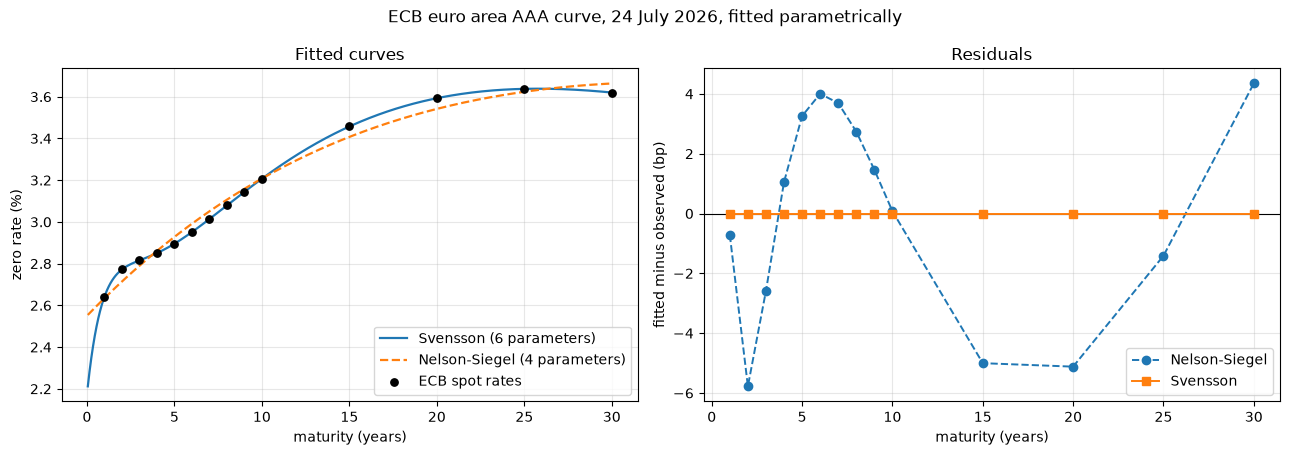

In [5]:
grid = np.linspace(0.05, 30.0, 600)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(grid, [100 * sv.zero(t) for t in grid], label="Svensson (6 parameters)", lw=1.6)
axes[0].plot(
    grid, [100 * ns.zero(t) for t in grid], label="Nelson-Siegel (4 parameters)", lw=1.6, ls="--"
)
axes[0].scatter(times, 100 * zeros, s=28, zorder=3, color="black", label="ECB spot rates")
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("zero rate (%)")
axes[0].set_title("Fitted curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].plot(times, ns_resid_bp, marker="o", lw=1.4, ls="--", label="Nelson-Siegel")
axes[1].plot(times, sv_resid_bp, marker="s", lw=1.4, label="Svensson")
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylabel("fitted minus observed (bp)")
axes[1].set_title("Residuals")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("ECB euro area AAA curve, 24 July 2026, fitted parametrically")
fig.tight_layout()
plt.show()

#
# ## Decomposing the fit into its factors
#
# Both models are linear in the betas, so a fitted curve is the sum of component
# curves obtained by keeping one beta and zeroing the rest. Building those
# components as `Svensson` objects and adding them back is a check on the claim as
# much as an illustration of it.

max |sum of components - fitted curve| = 0.000e+00


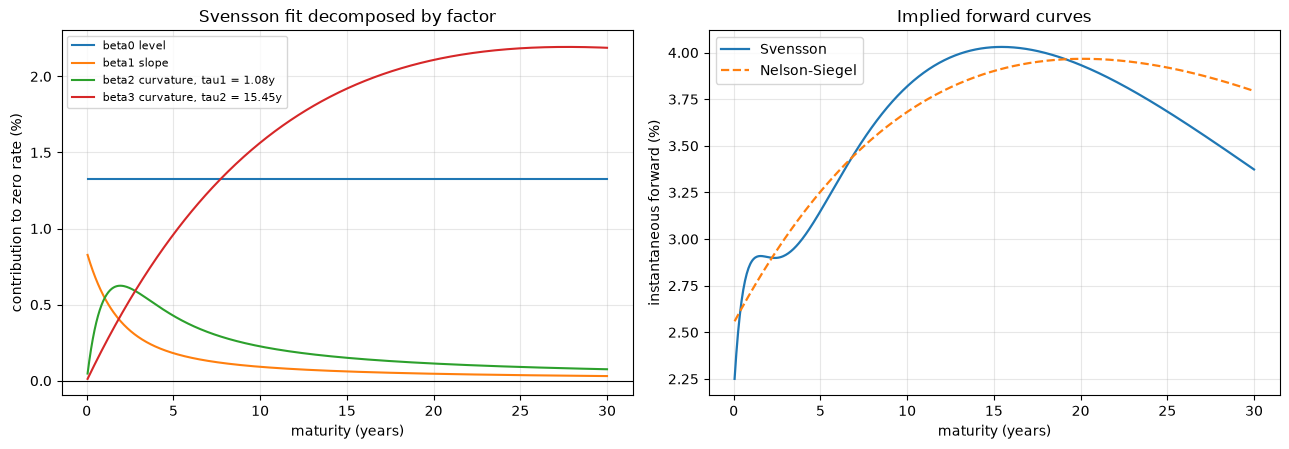

In [6]:
components = {
    f"beta{i}": Svensson(
        beta=tuple(b if j == i else 0.0 for j, b in enumerate(sv.beta)),  # type: ignore[arg-type]
        tau=sv.tau,
        reference_date=ASOF,
    )
    for i in range(4)
}

recombined = np.array([sum(c.zero(t) for c in components.values()) for t in grid])
direct = np.array([sv.zero(t) for t in grid])
print(f"max |sum of components - fitted curve| = {np.abs(recombined - direct).max():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

labels = {
    "beta0": "beta0 level",
    "beta1": "beta1 slope",
    "beta2": "beta2 curvature, tau1 = 1.08y",
    "beta3": "beta3 curvature, tau2 = 15.45y",
}
for name, curve in components.items():
    axes[0].plot(grid, [100 * curve.zero(t) for t in grid], lw=1.5, label=labels[name])
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("contribution to zero rate (%)")
axes[0].set_title("Svensson fit decomposed by factor")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(grid, [100 * sv.instantaneous_fwd(t) for t in grid], lw=1.6, label="Svensson")
axes[1].plot(
    grid, [100 * ns.fwd(t, t + 0.01) for t in grid], lw=1.6, ls="--", label="Nelson-Siegel"
)
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylabel("instantaneous forward (%)")
axes[1].set_title("Implied forward curves")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [7]:
# Diagnostics behind the interpretation below. Every figure quoted in the next
# markdown cell is printed here, so the prose can be checked against output.
fine = np.linspace(0.01, 30.0, 3000)


def _peak(component):
    """Maturity and value at which a Svensson component contributes most."""
    vals = [100 * component.zero(t) for t in fine]
    k = int(np.argmax(np.abs(vals)))
    return fine[k], vals[k]


b2_t, b2_v = _peak(components["beta2"])
b3_t, b3_v = _peak(components["beta3"])
print("Svensson component contributions (percentage points of the zero rate)")
print(
    f"  first curvature  peak {b2_v:6.2f}% at {b2_t:5.2f}y"
    f" | at  5y {100 * components['beta2'].zero(5.0):6.2f}%"
    f" | at 15y {100 * components['beta2'].zero(15.0):6.2f}%"
)
print(
    f"  second curvature peak {b3_v:6.2f}% at {b3_t:5.2f}y"
    f" | at 15y {100 * components['beta3'].zero(15.0):6.2f}%"
)

inside = fine[fine >= times.min()]
gaps = [abs(100 * (ns.zero(t) - sv.zero(t))) for t in inside]
k_gap = int(np.argmax(gaps))
print("\nNelson-Siegel against Svensson")
print(
    f"  widest zero-rate gap over the fitted span ({times.min():.0f}-30y) :"
    f" {100 * gaps[k_gap]:6.2f} bp at {inside[k_gap]:5.2f}y"
)
print(
    f"  forward-rate gap at 30 years                        :"
    f" {100 * 100 * (ns.fwd(30.0, 30.01) - sv.instantaneous_fwd(30.0)):6.2f} bp"
)

ns_short, sv_short = 100 * ns.zero(1e-9), 100 * sv.zero(1e-9)
print(f"\nExtrapolated to t -> 0, shorter than the {times.min():.0f}y shortest quote")
print(
    f"  Nelson-Siegel {ns_short:6.2f}%   Svensson {sv_short:6.2f}%"
    f"   gap {100 * (ns_short - sv_short):6.2f} bp"
)

Svensson component contributions (percentage points of the zero rate)
  first curvature  peak   0.62% at  1.94y | at  5y   0.43% | at 15y   0.15%
  second curvature peak   2.19% at 27.70y | at 15y   1.92%

Nelson-Siegel against Svensson
  widest zero-rate gap over the fitted span (1-30y) :   5.88 bp at  1.85y
  forward-rate gap at 30 years                        :  42.09 bp

Extrapolated to t -> 0, shorter than the 1y shortest quote
  Nelson-Siegel   2.55%   Svensson   2.17%   gap  37.75 bp


## Interpretation of results

**Nelson-Siegel residual structure.** The Nelson-Siegel residuals do not scatter
around zero. They alternate sign in four extended runs: negative at 1-3 years,
positive from 4-10, negative again at 15-25, and positive at 30. This banded
pattern identifies a structural deficiency. The model cannot express the curve's
shape because it has only one curvature term, allowing the forward curve to turn
once. The euro area curve turns twice: concave in the short end, convex in the
middle, concave again at long maturities. The least-squares fit distributes this
failure across all 14 points, producing residuals of 3.42 basis points RMSE
overall and 4.25 basis points over 15-30 years.

**Parameter identification at boundaries.** Nelson-Siegel's fitted $\beta_0 = 0.0001\%$
and $\tau = 30.000000$ years sit on the constraint bounds (floor $10^{-6}$, ceiling
30 years). When an optimizer returns a boundary solution, the parameter no longer
estimates the market; it estimates the constraint. The nominal reading, an
asymptotic long rate of 0.0001%, is inconsistent with the model's own 30-year
rate of 3.66%. The inconsistency reveals that the curve does not contain enough
information to identify the limit; with $\tau = 30$, the decay is so slow that
convergence has barely begun at 30 years. Svensson's $\beta_0 = 1.326\%$, by
contrast, sits comfortably interior to the constraints at $\tau_1 = 1.08$ and
$\tau_2 = 15.45$ years, signalling that both parameters are economically
meaningful.

**Two-tau structure.** Decomposing the Svensson fit into its four components
clarifies why two decay constants are essential. The $\beta_2$ term ($\tau_1 =
1.08$ years) peaks at 0.62% around 1.94 years and decays to 0.43% by five years
and 0.15% by fifteen. The $\beta_3$ term ($\tau_2 = 15.45$ years) is still
climbing at fifteen years (contributing 1.92%), reaching its peak of 2.19% at
27.7 years. The two terms operate in separate regions of the curve, which is the
entire purpose of estimating two decay scales. Nelson-Siegel's single scale cannot
capture this separation.

**Magnification of disagreement in forward rates.** At 30 years, the fitted zero
curves differ by 4.3 basis points. Their forward curves at the same point are
42.1 basis points apart, roughly ten times wider. The mechanism, identified in
notebook 02, is that the forward rate is a derivative of the fitted curve.
Disagreement about shape averages away in zero rates but magnifies in derivatives.
Within the fitted range, the two zero curves stay within 5.9 basis points (near
1.85 years). Extrapolated back to $t = 0$, Nelson-Siegel implies 2.55% against
Svensson's 2.17%, a 37.75 basis point gap at a maturity shorter than any
observation either model received.

## Extrapolation, and why regulators legislate it

The parametric form is defined for all $t$, so both models will return a rate at
40 or 50 years without complaint. Neither has seen any data past 30.

In [8]:
print(
    f"{'maturity':>9} {'NS zero %':>11} {'SV zero %':>11} {'diff bp':>9} "
    f"{'NS fwd %':>10} {'SV fwd %':>10}"
)
for t in (20.0, 30.0, 40.0, 50.0):
    print(
        f"{t:>9.0f} {100 * ns.zero(t):>11.4f} {100 * sv.zero(t):>11.4f} "
        f"{1e4 * (ns.zero(t) - sv.zero(t)):>9.1f} "
        f"{100 * ns.fwd(t, t + 0.01):>10.4f} {100 * sv.instantaneous_fwd(t):>10.4f}"
    )

 maturity   NS zero %   SV zero %   diff bp   NS fwd %   SV fwd %
       20      3.5417      3.5929      -5.1     3.9667     3.9337
       30      3.6635      3.6200       4.3     3.7943     3.3734
       40      3.6499      3.4794      17.1     3.4009     2.7549
       50      3.5532      3.2826      27.1     2.9256     2.2609


Inside the fitted range, at 20 years, the two models differ by 5 basis points.
At 40 years the gap is 17 basis points and at 50 it is 27, with the forward rates
66 basis points apart. Neither number is supported by anything: both are the
functional form talking, and the functional forms disagree because the
constraints that pinned them down have run out.

This is not an academic concern. A euro area insurer discounting annuity
liabilities, or a pension scheme with cash flows past its longest available
bond, is exposed directly to this choice, and 27 basis points at 50 years is a
material valuation difference on a long liability.

It is also why the extrapolation of the risk-free curve for insurance liabilities
is not left to the firm's curve fitter. Under **Solvency II**, EIOPA publishes the
risk-free interest rate term structures that firms must use, extrapolated beyond
the last liquid point by the Smith-Wilson technique towards an Ultimate Forward
Rate set by the regulator. Both the last liquid point and the UFR are prescribed
rather than fitted, which removes exactly the discretion this table exposes. The
principle generalises past insurance: where the market stops supplying
information, the number a model returns is a policy choice, and supervisors treat
it as one.

## Regulatory and control context

**IFRS 13.** A parametric curve is a valuation technique in the sense of IFRS 13,
and its inputs sit at different levels of the fair value hierarchy depending on
where they came from. Zero rates read off a curve fitted to observable government
bond quotes at maturities where those quotes exist are Level 2. The 50 year rate
in the table above, produced by extrapolating a model past its data, is not: it
depends on an unobservable input, the assumed asymptotic shape, and it is
significant to the measurement. Where the curve stops being observable is
therefore an accounting question, not just a modelling one.

**CRR Article 105 and the EBA prudent valuation RTS.** The market price
uncertainty additional valuation adjustment requires an institution to hold
capital against the range of plausible values a position could take. When two
defensible model specifications differ by 27 basis points at 50 years, that range
is not hypothetical and it is measurable. The calculation above is the kind of
evidence a prudent valuation assessment is built from.

**Model risk.** The boundary solution found for Nelson-Siegel is the sort of
finding a model validation function exists to catch. The fit reprices the curve to
within 6 basis points everywhere and plots convincingly, yet one of its four
parameters is pinned to a constraint and its stated economic meaning is wrong. A
validation review that inspected only the residuals would pass it.

## Limitations of this implementation

Two are worth recording rather than leaving for a reader to discover.

**The positive short rate constraint.** Both fitters reject any candidate with
$\beta_0 + \beta_1 \le 10^{-6}$, so neither can represent a negative instantaneous
short rate. For euro area data between 2015 and 2022 that is not a safeguard, it
is a specification error: the short end of the euro curve was genuinely negative
for most of that period, and this fitter could not have described it. The
constraint is defensible for the July 2026 curve fitted here, where the one year
rate is 2.64%, and it is not defensible in general. Notebook 02 made the opposite
choice in the interpolation layer, deliberately omitting the Hagan-West positivity
amendment for precisely this reason. The inconsistency between the two modules is
real and this notebook is the right place to say so.

**The bounds are not neutral.** The Nelson-Siegel fit above hit two of them. A
fitter that silently returns boundary solutions should say so, and this one does
not. Reporting which constraints are active at the optimum would be a genuine
improvement to `yieldcurve.curves.parametric`.

## Summary

Two parametric models were fitted to the 14 point ECB euro area AAA spot curve
for 24 July 2026.

The Svensson fit recovered the ECB's six published parameters to about eight
significant figures, from the spot rates alone. Because the ECB generates those
spot rates from its own Svensson estimation, that agreement is a verification of
this implementation's functional form and optimiser, not evidence about how well
Svensson prices bonds.

Nelson-Siegel, the same model without the second curvature term, fitted the same
14 points with a 3.42 basis point RMSE, rising to 4.25 basis points over the 15
to 30 year segment, with a largest single residual of 5.78 basis points at 2
years. Its residuals alternate sign in four extended runs, which identifies the
problem as missing shape rather than imprecision: one curvature term cannot turn
the forward curve twice, and this curve turns twice.

The Nelson-Siegel fit also came back with $\beta_0$ on its lower bound and $\tau$
on its upper bound, making its nominal long-run level of 0.0001% an artefact of
the constraint set rather than a statement about the euro area. The same fitted
curve returns 3.66% at 30 years. Parameters have to be read, not just residuals.

Extrapolated past the data the two models diverge by 27 basis points at 50 years,
a spread that comes entirely from functional form. That is the gap Solvency II
closes by prescribing Smith-Wilson extrapolation to a regulated Ultimate Forward
Rate, and it is the gap prudent valuation is meant to capitalise.

Notebook 04 leaves single-currency curve shape behind and takes up the
post-2008 multi-curve framework, where discounting and forecasting are done off
separate curves.